# LSTM Train Model

## Base Initialization

### Global Parameters

In [37]:
stock_code = "GAS"

In [38]:
output_column = "close"

In [39]:
stock_code = str.lower(stock_code)

### Install libraries

In [40]:
# !pip install -r requirements.txt

### Import libraries

In [41]:
import os
import sys
import random
import numpy as np
import torch

# Set CUBLAS_WORKSPACE_CONFIG for reproducibility
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from data_preprocessor.data_preprocessor import DataPreprocessor
from dtos.model_dtos.model_config_dto import ModelConfigDto
from logger.logger import Logger, LogType
from model.lstm_model import LSTM_Model
from train_test_creator.train_test_creator import TrainTestCreator
from web_scraper.web_scraper import WebScraper
from utils.constants import *
from utils.enums import *
from utils.utils import plot_model_result

os.environ["WANDB_DISABLE_SYMLINKS"] = "true"

In [42]:
SEED = RANDOM_SEED

# Apply globally
random.seed(SEED)
np.random.seed(SEED)

In [43]:
input_size = DEFAULT_INPUT_SIZE
forecast_size = DEFAULT_FORECAST_SIZE

print(f"Input size: {input_size}")
print(f"Forecast size: {forecast_size}")

Input size: 240
Forecast size: 30


### Log Metadata

In [44]:
my_logger = Logger(
    file_name=f"{TRAINED_MODELS_LOG_FILE_BASE}/{stock_code}_lstm_train_log"
)

In [45]:
my_logger.log_info(
    f"\nTRAIN MODEL FOR STOCK: '{stock_code}' - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
)

### Load Dataframe

In [46]:
my_train_test_creator = TrainTestCreator(logger=my_logger)

In [47]:
dataframe = my_train_test_creator.load_dataframe(
    stock_code=stock_code, file_path=f"../../unified_dataframe/unified_{stock_code}.csv"
)
dataframe

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,eom_20,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10
0,2013-03-06,4.707945,42.573445,318.035806,275.767367,9.470968,428.666774,40.638065,31.087742,1423.448966,...,-0.037691,0.044115,1220.608792,964.909607,0.144175,0.147936,-0.003761,69.547974,522.980011,-7875.073746
1,2013-03-07,4.710027,42.585916,324.596774,275.848142,9.706129,428.922903,41.177742,31.329032,1423.865911,...,0.006026,0.045669,1212.631110,964.909607,0.140278,0.146404,-0.006126,45.861928,454.820285,-25492.795995
2,2013-03-08,4.712110,42.598386,331.157742,275.928918,9.941290,429.179032,41.717419,31.570323,1424.282855,...,-0.031238,0.021012,1212.631110,964.909607,0.135737,0.144271,-0.008534,-34.331403,384.941472,-14313.561330
3,2013-03-11,4.718356,42.635797,350.840645,276.171244,10.646774,429.947419,43.336452,32.294194,1425.533689,...,-0.087321,0.025443,1212.631110,964.909607,0.130898,0.141596,-0.010698,-64.185869,320.780424,-8878.216392
4,2013-03-12,4.720438,42.648267,357.401613,276.252019,10.881935,430.203548,43.876129,32.535484,1425.950634,...,-0.063236,0.059730,1217.949564,964.909607,0.126369,0.138551,-0.012182,-53.492223,267.312903,1734.980337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3022,2025-06-20,7.846813,106.966667,936.533333,579.360000,72.863333,315.580000,222.863333,224.926667,2770.786667,...,0.405180,0.028466,4676.758295,839.897191,0.030031,0.022065,0.007966,6608.683126,4585.012125,-162996.860877
3023,2025-06-23,7.880769,106.676667,927.445333,586.434000,71.482333,302.707000,222.304333,227.240667,2738.915667,...,0.454877,0.061912,4885.361903,839.897191,0.034203,0.024492,0.009711,7724.802154,5033.553558,-8951.424861
3024,2025-06-25,7.903407,106.483333,921.386667,591.150000,70.561667,294.125000,221.931667,228.783333,2717.668333,...,0.247208,0.001295,4885.361903,780.896149,0.037826,0.027159,0.010667,6231.077840,5204.628455,-328713.260795
3025,2025-06-26,7.914725,106.386667,918.357333,593.508000,70.101333,289.834000,221.745333,229.554667,2707.044667,...,0.120171,-0.002004,4885.361903,792.464981,0.040591,0.029846,0.010746,5858.265949,5298.005240,-155238.649006


In [48]:
dataframe.shape

(3027, 356)

## Find output range

In [49]:
dataframe.close.min(), dataframe.close.max()

(15.7183, 95.4676)

## Create train test set

In [50]:
train_test_set = my_train_test_creator.create_train_test_set(
    dataframe=dataframe,
    output_column=output_column,
    stock_code=stock_code,
    input_size=input_size,
    forecast_size=forecast_size,
)

Feature Selector Types:
['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']

Fitting feature selectors...

Fitting XGB feature selector...
Done fitting XGB feature selector...
Fitting LASSO feature selector...


d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.352e+02, tolerance: 8.633e+01
  model = cd_fast.enet_coordinate_descent(


Done fitting LASSO feature selector...
Fitting ELASTC NET feature selector...


d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.825e+02, tolerance: 8.633e+01
  model = cd_fast.enet_coordinate_descent(


Done fitting ELASTC NET feature selector...
Fitting XGB SHAP feature selector...
Done fitting XGB SHAP feature selector...

Done fitting feature selectors...
🔍 Dropped 25 highly correlated features (|r| >= 0.85):
['close_bb_lower_20', 'close_bb_middle_20', 'close_bb_upper_20', 'close_ema_12', 'close_ema_26', 'close_lwma_12', 'close_lwma_26', 'close_lwma_50', 'close_sma_50', 'close_wma_100', 'close_wma_14', 'close_wma_21', 'close_wma_50', 'close_wma_7', 'kc_lower_20', 'kc_middle_20', 'kc_upper_20', 'low', 'macd_signal_9', 'open', 'roc_9', 'starc_lower_20', 'starc_middle_20', 'starc_upper_20', 'vn_index_close']
✅ Kept 15 features after pruning correlation redundancy.


### Train set

In [51]:
train_test_set.get_train_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,4.707945,42.573445,318.035806,275.767367,9.470968,428.666774,40.638065,31.087742,1423.448966,111.510968,...,0.044115,1220.608792,964.909607,0.144175,0.147936,-0.003761,69.547974,522.980011,-7875.073746,20.8390
1,4.710027,42.585916,324.596774,275.848142,9.706129,428.922903,41.177742,31.329032,1423.865911,113.366129,...,0.045669,1212.631110,964.909607,0.140278,0.146404,-0.006126,45.861928,454.820285,-25492.795995,20.7028
2,4.712110,42.598386,331.157742,275.928918,9.941290,429.179032,41.717419,31.570323,1424.282855,115.221290,...,0.021012,1212.631110,964.909607,0.135737,0.144271,-0.008534,-34.331403,384.941472,-14313.561330,20.7028
3,4.718356,42.635797,350.840645,276.171244,10.646774,429.947419,43.336452,32.294194,1425.533689,120.786774,...,0.025443,1212.631110,964.909607,0.130898,0.141596,-0.010698,-64.185869,320.780424,-8878.216392,20.7028
4,4.720438,42.648267,357.401613,276.252019,10.881935,430.203548,43.876129,32.535484,1425.950634,122.641935,...,0.059730,1217.949564,964.909607,0.126369,0.138551,-0.012182,-53.492223,267.312903,1734.980337,20.7936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2482,3.365055,88.488919,725.000000,375.000000,58.333333,283.333333,235.000000,241.666667,2983.333333,225.000000,...,-0.606771,2816.616686,1496.399958,0.022228,0.022396,-0.000167,-89.956999,47.701552,-15524.339473,74.5743
2483,3.374066,88.501389,726.000000,380.000000,58.000000,280.000000,234.000000,240.000000,2960.000000,224.000000,...,-0.575348,2805.561621,1496.399958,0.022512,0.022419,0.000093,-152.219930,19.141340,-20366.324597,74.2816
2484,3.383077,88.513859,727.000000,385.000000,57.666667,276.666667,233.000000,238.333333,2936.666667,223.000000,...,-0.967230,2805.561621,1491.976125,0.022636,0.022462,0.000174,-152.245452,-5.342487,-10665.212351,74.0620
2485,3.410110,88.551270,730.000000,400.000000,56.666667,266.666667,230.000000,233.333333,2866.666667,220.000000,...,-1.030053,2758.433550,1491.976125,0.022956,0.022561,0.000395,-343.665407,-53.674333,-38599.605251,72.8179


In [52]:
train_test_set.get_train_set().shape

(2487, 330)

### Val set

In [53]:
train_test_set.get_val_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,3.428132,88.576211,732.000000,410.000000,56.000000,260.000000,228.000000,230.000000,2820.000000,218.000000,...,-1.057625,2755.675516,1497.973296,0.023408,0.022832,0.000576,-207.645620,-111.224745,33637.959159,73.0375
1,3.437143,88.588681,733.000000,415.000000,55.666667,256.666667,227.000000,228.333333,2796.666667,217.000000,...,-0.997026,2755.675516,1500.973857,0.023498,0.022965,0.000533,-126.432862,-113.397333,17477.438576,73.1838
2,3.446154,88.601151,734.000000,420.000000,55.333333,253.333333,226.000000,226.666667,2773.333333,216.000000,...,-1.004246,2703.317388,1500.973857,0.023575,0.023087,0.000488,-256.456384,-133.834340,-15771.911702,71.7933
3,7.892088,106.580000,924.416000,588.792000,71.022000,298.416000,222.118000,228.012000,2728.292000,124.636000,...,-1.003336,2601.903402,1500.973857,0.025575,0.023585,0.001990,-2088.535512,-413.077365,-100965.279353,69.1000
4,3.473187,88.638562,737.000000,435.000000,54.333333,243.333333,223.000000,221.666667,2703.333333,213.000000,...,-0.869786,2601.903402,1545.171129,0.027074,0.024282,0.002791,-1799.654268,-611.159779,-27609.382753,71.1347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,6.022857,93.314907,719.798667,720.000000,63.666667,263.333333,238.000000,250.000000,2830.000000,200.666667,...,-0.183585,3895.398558,970.427470,0.077188,0.084045,-0.006857,-2551.154040,-1495.739446,-61334.948902,66.8850
266,6.106593,93.389728,733.225806,718.709677,65.322581,244.516129,213.225806,245.806452,2820.967742,165.161290,...,-0.200430,3895.398558,975.708708,0.075070,0.082250,-0.007180,-2633.047341,-1658.212003,25455.921604,67.2490
267,6.120549,93.402199,734.838710,718.064516,65.483871,241.774194,214.838710,243.709677,2806.451613,162.741935,...,-0.161626,3895.398558,979.669637,0.072858,0.080371,-0.007513,-2336.410140,-1755.097451,67979.202500,67.5220
268,6.952637,110.796667,884.220000,611.966667,56.058000,471.487333,260.274667,241.383333,2951.042667,182.221333,...,-0.223104,3895.398558,973.546883,0.070440,0.078385,-0.007945,-2214.506095,-1820.727257,38630.482103,67.1000


In [54]:
train_test_set.get_val_set().shape

(270, 330)

### Test set

In [55]:
train_test_set.get_test_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,6.176374,93.452080,741.290323,715.483871,66.129032,230.806452,221.290323,235.322581,2748.387097,153.064516,...,-0.202471,4030.837677,973.546883,0.066830,0.074458,-0.007629,-1055.906693,-1717.764409,164468.033462,69.433
1,6.190330,93.464550,742.903226,714.838710,66.290323,228.064516,222.903226,233.225806,2733.870968,150.645161,...,-0.108551,4030.837677,987.582290,0.065916,0.072750,-0.006834,-60.184028,-1480.967211,82719.021980,70.434
2,6.963956,111.175000,884.815000,613.200000,56.697000,468.836000,260.322000,241.360000,2951.754000,181.682000,...,-0.338947,3576.786137,987.582290,0.065179,0.071236,-0.006056,-2043.371456,-1561.310675,-162550.080938,62.500
3,6.204286,93.477020,744.516129,714.193548,66.451613,225.322581,224.516129,231.129032,2719.354839,148.225806,...,-0.130992,3576.786137,1094.256979,0.064370,0.069863,-0.005492,-1582.991310,-1564.407909,-14235.604524,69.251
4,6.218242,93.489490,746.129032,713.548387,66.612903,222.580645,226.129032,229.032258,2704.838710,145.806452,...,-0.161036,3576.786137,1085.629460,0.063417,0.068574,-0.005156,-1812.295360,-1599.820402,-50310.841336,68.705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,7.846813,106.966667,936.533333,579.360000,72.863333,315.580000,222.863333,224.926667,2770.786667,128.453333,...,0.028466,4676.758295,839.897191,0.030031,0.022065,0.007966,6608.683126,4585.012125,-162996.860877,69.500
266,7.880769,106.676667,927.445333,586.434000,71.482333,302.707000,222.304333,227.240667,2738.915667,125.590333,...,0.061912,4885.361903,839.897191,0.034203,0.024492,0.009711,7724.802154,5033.553558,-8951.424861,72.600
267,7.903407,106.483333,921.386667,591.150000,70.561667,294.125000,221.931667,228.783333,2717.668333,123.681667,...,0.001295,4885.361903,780.896149,0.037826,0.027159,0.010667,6231.077840,5204.628455,-328713.260795,67.500
268,7.914725,106.386667,918.357333,593.508000,70.101333,289.834000,221.745333,229.554667,2707.044667,122.727333,...,-0.002004,4885.361903,792.464981,0.040591,0.029846,0.010746,5858.265949,5298.005240,-155238.649006,68.500


In [56]:
train_test_set.get_test_set().shape

(270, 330)

### Normalized train set

In [57]:
train_test_set.get_norm_train_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.548284,0.000000,0.000000,0.202851,0.000000,0.542525,0.000000,0.000000,0.005678,0.261530,...,0.233857,0.000875,0.467761,0.578960,0.593050,0.304170,0.443745,0.486007,0.447933,0.064210
1,0.548388,0.000190,0.008390,0.202981,0.003334,0.542947,0.002586,0.000781,0.005779,0.269747,...,0.233961,0.000000,0.467761,0.571400,0.590011,0.279650,0.442942,0.482295,0.432703,0.062502
2,0.548493,0.000379,0.016781,0.203111,0.006668,0.543370,0.005171,0.001562,0.005880,0.277963,...,0.232312,0.000000,0.467761,0.562588,0.585776,0.254679,0.440227,0.478488,0.442367,0.062502
3,0.548808,0.000948,0.041952,0.203502,0.016671,0.544638,0.012928,0.003905,0.006182,0.302612,...,0.232609,0.000000,0.467761,0.553199,0.580468,0.232236,0.439216,0.474994,0.447066,0.062502
4,0.548913,0.001138,0.050342,0.203632,0.020005,0.545061,0.015514,0.004687,0.006283,0.310828,...,0.234901,0.000583,0.467761,0.544412,0.574424,0.216856,0.439578,0.472081,0.456240,0.063641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2482,0.480598,0.698371,0.520438,0.362903,0.692798,0.302625,0.931223,0.681679,0.383374,0.764161,...,0.190335,0.175914,0.878006,0.342345,0.343892,0.341436,0.438343,0.460120,0.441320,0.738013
2483,0.481052,0.698560,0.521717,0.370968,0.688072,0.297123,0.926432,0.676283,0.377724,0.759732,...,0.192436,0.174702,0.878006,0.342896,0.343939,0.344137,0.436235,0.458564,0.437135,0.734342
2484,0.481506,0.698750,0.522996,0.379032,0.683346,0.291621,0.921641,0.670888,0.372074,0.755304,...,0.166232,0.174702,0.874591,0.343136,0.344025,0.344971,0.436234,0.457231,0.445521,0.731589
2485,0.482868,0.699319,0.526833,0.403226,0.669167,0.275114,0.907267,0.654702,0.355125,0.742017,...,0.162031,0.169533,0.874591,0.343757,0.344221,0.347263,0.429752,0.454598,0.421373,0.715989


### Normalized val set

In [58]:
train_test_set.get_norm_val_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.483777,0.699698,0.529390,0.419355,0.659715,0.264109,0.897685,0.643912,0.343826,0.733159,...,0.160188,0.169231,0.879220,0.344634,0.344758,0.349145,0.434358,0.451463,0.483819,0.718742
1,0.484231,0.699888,0.530669,0.427419,0.654988,0.258607,0.892894,0.638517,0.338176,0.728730,...,0.164240,0.169231,0.881536,0.344809,0.345023,0.348696,0.437108,0.451345,0.469849,0.720577
2,0.484685,0.700078,0.531948,0.435484,0.650262,0.253105,0.888103,0.633121,0.332526,0.724301,...,0.163757,0.163488,0.881536,0.344958,0.345265,0.348228,0.432705,0.450232,0.441106,0.703141
3,0.708775,0.973535,0.775458,0.707729,0.872705,0.327522,0.869503,0.637476,0.321620,0.319660,...,0.163818,0.152366,0.881536,0.348838,0.346252,0.363806,0.370664,0.435022,0.367461,0.669369
4,0.486048,0.700647,0.535784,0.459677,0.636084,0.236598,0.873729,0.616935,0.315577,0.711015,...,0.172748,0.152366,0.915651,0.351747,0.347637,0.372115,0.380446,0.424233,0.430873,0.694883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,0.614559,0.771774,0.513787,0.919355,0.768417,0.269611,0.945597,0.708655,0.346247,0.656392,...,0.218632,0.294228,0.472020,0.448984,0.466247,0.272068,0.354998,0.376052,0.401719,0.641594
266,0.618780,0.772912,0.530958,0.917274,0.791895,0.238550,0.826899,0.695080,0.344060,0.499142,...,0.217505,0.294228,0.476097,0.444875,0.462684,0.268719,0.352225,0.367203,0.476746,0.646159
267,0.619483,0.773101,0.533020,0.916233,0.794182,0.234024,0.834627,0.688292,0.340545,0.488427,...,0.220100,0.294228,0.479154,0.440583,0.458956,0.265261,0.362270,0.361926,0.513505,0.649582
268,0.661423,1.037670,0.724054,0.745108,0.660537,0.613208,1.052319,0.680762,0.375555,0.574699,...,0.215989,0.294228,0.474428,0.435891,0.455014,0.260783,0.366398,0.358351,0.488134,0.644290


### Normalized test set

In [59]:
train_test_set.get_norm_test_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.622297,0.773860,0.541271,0.912071,0.803330,0.215920,0.865538,0.661142,0.326486,0.445567,...,0.217369,0.309082,0.474428,0.428886,0.447221,0.264066,0.405632,0.363959,0.596914,0.673544
1,0.623000,0.774050,0.543334,0.911030,0.805617,0.211394,0.873266,0.654354,0.322971,0.434852,...,0.223649,0.309082,0.485262,0.427113,0.443830,0.272304,0.439351,0.376857,0.526247,0.686096
2,0.661994,1.043424,0.724815,0.747097,0.669597,0.608831,1.052546,0.680686,0.375727,0.572311,...,0.208243,0.259284,0.485262,0.425684,0.440825,0.280369,0.372193,0.372481,0.314224,0.586610
3,0.623704,0.774239,0.545396,0.909990,0.807903,0.206868,0.880993,0.647567,0.319456,0.424137,...,0.222148,0.259284,0.567601,0.424114,0.438100,0.286219,0.387783,0.372312,0.442434,0.671262
4,0.624407,0.774429,0.547459,0.908949,0.810190,0.202342,0.888721,0.640779,0.315942,0.413422,...,0.220139,0.259284,0.560942,0.422265,0.435541,0.289703,0.380018,0.370383,0.411249,0.664416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,0.706493,0.979416,0.790954,0.692516,0.898812,0.355854,0.873074,0.627489,0.331910,0.336566,...,0.232811,0.379922,0.371267,0.357485,0.343236,0.425776,0.665184,0.707256,0.313838,0.674385
266,0.708204,0.975005,0.779332,0.703926,0.879232,0.334605,0.870396,0.634979,0.324193,0.323887,...,0.235047,0.402800,0.371267,0.365580,0.348054,0.443864,0.702980,0.731687,0.447002,0.713256
267,0.709345,0.972064,0.771584,0.711532,0.866178,0.320439,0.868611,0.639973,0.319048,0.315433,...,0.230994,0.402800,0.325725,0.372610,0.353347,0.453780,0.652397,0.741005,0.170585,0.649306
268,0.709916,0.970594,0.767710,0.715335,0.859651,0.313356,0.867718,0.642470,0.316476,0.311207,...,0.230773,0.402800,0.334655,0.377975,0.358678,0.454596,0.639772,0.746091,0.320545,0.661845


### Train windows

In [60]:
print(f"Number of train windows: {len(train_test_set.get_train_windows())}")

Number of train windows: 2218


In [61]:
train_test_set.get_train_windows()[0]

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.548284,0.000000,0.000000,0.202851,0.000000,0.542525,0.000000,0.000000,0.005678,0.261530,...,0.233857,0.000875,0.467761,0.578960,0.593050,0.304170,0.443745,0.486007,0.447933,0.064210
1,0.548388,0.000190,0.008390,0.202981,0.003334,0.542947,0.002586,0.000781,0.005779,0.269747,...,0.233961,0.000000,0.467761,0.571400,0.590011,0.279650,0.442942,0.482295,0.432703,0.062502
2,0.548493,0.000379,0.016781,0.203111,0.006668,0.543370,0.005171,0.001562,0.005880,0.277963,...,0.232312,0.000000,0.467761,0.562588,0.585776,0.254679,0.440227,0.478488,0.442367,0.062502
3,0.548808,0.000948,0.041952,0.203502,0.016671,0.544638,0.012928,0.003905,0.006182,0.302612,...,0.232609,0.000000,0.467761,0.553199,0.580468,0.232236,0.439216,0.474994,0.447066,0.062502
4,0.548913,0.001138,0.050342,0.203632,0.020005,0.545061,0.015514,0.004687,0.006283,0.310828,...,0.234901,0.000583,0.467761,0.544412,0.574424,0.216856,0.439578,0.472081,0.456240,0.063641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,0.568037,0.076817,0.415868,0.255615,0.176580,0.400291,0.134114,0.142524,0.046565,0.850525,...,0.247518,0.108423,0.601249,0.661802,0.637466,0.514824,0.438292,0.446309,0.392620,0.358600
266,0.568171,0.077007,0.418362,0.255745,0.177237,0.394937,0.134594,0.143010,0.046665,0.840560,...,0.243296,0.108423,0.577639,0.674645,0.646664,0.535400,0.424465,0.444022,0.367487,0.343662
267,0.568305,0.077196,0.420856,0.255876,0.177894,0.389583,0.135073,0.143497,0.046766,0.830595,...,0.239785,0.108423,0.591804,0.686477,0.656444,0.547542,0.432651,0.443942,0.390498,0.352624
268,0.568439,0.077386,0.423350,0.256006,0.178551,0.384229,0.135552,0.143983,0.046867,0.820630,...,0.241418,0.108423,0.582360,0.696034,0.666222,0.547525,0.424245,0.441943,0.376076,0.346649


### Val windows

In [62]:
print(f"Number of val windows: {len(train_test_set.get_val_windows())}")

Number of val windows: 1


In [63]:
train_test_set.get_val_windows()[0]

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.483777,0.699698,0.529390,0.419355,0.659715,0.264109,0.897685,0.643912,0.343826,0.733159,...,0.160188,0.169231,0.879220,0.344634,0.344758,0.349145,0.434358,0.451463,0.483819,0.718742
1,0.484231,0.699888,0.530669,0.427419,0.654988,0.258607,0.892894,0.638517,0.338176,0.728730,...,0.164240,0.169231,0.881536,0.344809,0.345023,0.348696,0.437108,0.451345,0.469849,0.720577
2,0.484685,0.700078,0.531948,0.435484,0.650262,0.253105,0.888103,0.633121,0.332526,0.724301,...,0.163757,0.163488,0.881536,0.344958,0.345265,0.348228,0.432705,0.450232,0.441106,0.703141
3,0.708775,0.973535,0.775458,0.707729,0.872705,0.327522,0.869503,0.637476,0.321620,0.319660,...,0.163818,0.152366,0.881536,0.348838,0.346252,0.363806,0.370664,0.435022,0.367461,0.669369
4,0.486048,0.700647,0.535784,0.459677,0.636084,0.236598,0.873729,0.616935,0.315577,0.711015,...,0.172748,0.152366,0.915651,0.351747,0.347637,0.372115,0.380446,0.424233,0.430873,0.694883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,0.614559,0.771774,0.513787,0.919355,0.768417,0.269611,0.945597,0.708655,0.346247,0.656392,...,0.218632,0.294228,0.472020,0.448984,0.466247,0.272068,0.354998,0.376052,0.401719,0.641594
266,0.618780,0.772912,0.530958,0.917274,0.791895,0.238550,0.826899,0.695080,0.344060,0.499142,...,0.217505,0.294228,0.476097,0.444875,0.462684,0.268719,0.352225,0.367203,0.476746,0.646159
267,0.619483,0.773101,0.533020,0.916233,0.794182,0.234024,0.834627,0.688292,0.340545,0.488427,...,0.220100,0.294228,0.479154,0.440583,0.458956,0.265261,0.362270,0.361926,0.513505,0.649582
268,0.661423,1.037670,0.724054,0.745108,0.660537,0.613208,1.052319,0.680762,0.375555,0.574699,...,0.215989,0.294228,0.474428,0.435891,0.455014,0.260783,0.366398,0.358351,0.488134,0.644290


### Test windows

In [64]:
print(f"Number of test windows: {len(train_test_set.get_test_windows())}")

Number of test windows: 1


In [65]:
train_test_set.get_test_windows()[0]

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.622297,0.773860,0.541271,0.912071,0.803330,0.215920,0.865538,0.661142,0.326486,0.445567,...,0.217369,0.309082,0.474428,0.428886,0.447221,0.264066,0.405632,0.363959,0.596914,0.673544
1,0.623000,0.774050,0.543334,0.911030,0.805617,0.211394,0.873266,0.654354,0.322971,0.434852,...,0.223649,0.309082,0.485262,0.427113,0.443830,0.272304,0.439351,0.376857,0.526247,0.686096
2,0.661994,1.043424,0.724815,0.747097,0.669597,0.608831,1.052546,0.680686,0.375727,0.572311,...,0.208243,0.259284,0.485262,0.425684,0.440825,0.280369,0.372193,0.372481,0.314224,0.586610
3,0.623704,0.774239,0.545396,0.909990,0.807903,0.206868,0.880993,0.647567,0.319456,0.424137,...,0.222148,0.259284,0.567601,0.424114,0.438100,0.286219,0.387783,0.372312,0.442434,0.671262
4,0.624407,0.774429,0.547459,0.908949,0.810190,0.202342,0.888721,0.640779,0.315942,0.413422,...,0.220139,0.259284,0.560942,0.422265,0.435541,0.289703,0.380018,0.370383,0.411249,0.664416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,0.706493,0.979416,0.790954,0.692516,0.898812,0.355854,0.873074,0.627489,0.331910,0.336566,...,0.232811,0.379922,0.371267,0.357485,0.343236,0.425776,0.665184,0.707256,0.313838,0.674385
266,0.708204,0.975005,0.779332,0.703926,0.879232,0.334605,0.870396,0.634979,0.324193,0.323887,...,0.235047,0.402800,0.371267,0.365580,0.348054,0.443864,0.702980,0.731687,0.447002,0.713256
267,0.709345,0.972064,0.771584,0.711532,0.866178,0.320439,0.868611,0.639973,0.319048,0.315433,...,0.230994,0.402800,0.325725,0.372610,0.353347,0.453780,0.652397,0.741005,0.170585,0.649306
268,0.709916,0.970594,0.767710,0.715335,0.859651,0.313356,0.867718,0.642470,0.316476,0.311207,...,0.230773,0.402800,0.334655,0.377975,0.358678,0.454596,0.639772,0.746091,0.320545,0.661845


## Setup model

In [66]:
lstm_model_config = ModelConfigDto(
    # Metadata
    entity=WANDB_ENTITY_NAME,
    project=WANDB_PROJECT_NAME,
    architecture=AchitectureType.LSTM,
    stock_code=stock_code,
    # Windowing
    window_type=WindowType.SLIDING,
    input_size=input_size,
    forecast_size=forecast_size,
    # Training
    epochs=400,
    learning_rate=0.001,
    batch_size=64,
    optimizer=OptimizerType.ADAM,
    loss_fn=LossFunctionType.MSE,
    # Data & metrics
    scaler_type=ScalerType.MINMAX,
    metric=MetricType.MAPE,
    # Reproducibility & runtime
    seed=RANDOM_SEED,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)
lstm_model_config.format_config()

{
    "entity": "trung-lyduc18",
    "project": "master_thesis",
    "architecture": "lstm",
    "stock_code": "gas",
    "window_type": "sliding",
    "input_size": 240,
    "forecast_size": 30,
    "epochs": 400,
    "learning_rate": 0.001,
    "batch_size": 64,
    "optimizer": "adam",
    "loss_fn": "mse",
    "scaler_type": "minmax",
    "metric": "mape",
    "device": "cuda",
    "seed": 42,
    "lr_scheduler": null
}


In [67]:
my_lstm_model = LSTM_Model(
    logger=my_logger, train_test_set=train_test_set, model_config=lstm_model_config
)

PyTorch version: 2.5.1+cu121


## Start training the model

In [68]:
model_output_dto = my_lstm_model.train()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\ADMIN\_netrc


Training on cuda for 400 epochs...



Epoch 1:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch [1/400] - Train: 0.08778541 | Val: 0.00314919 | LR: 9.999846e-04


Epoch 2:   0%|          | 0/35 [00:00<?, ?it/s]

...

Epoch [15/400] - Train: 0.00168676 | Val: 0.00707006 | LR: 9.965342e-04


Epoch 16:   0%|          | 0/35 [00:00<?, ?it/s]

wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.
wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.


Early stopping at epoch 16 (best val loss: 0.003149)
Training completed in 28.97s | Test MAPE: 6.35%


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇██
learning_rate,████▇▇▆▆▅▅▄▄▃▂▁▁
test_mae,▁
test_mape,▁
test_r2,▁
test_rmse,▁
train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,▁▃▃▄▃█▄▅▁▆▄▅▃▅▃▃
epoch,15
learning_rate,0.001
test_mae,4.04389


In [69]:
model_output_dto.mape

6.347744171806424

In [70]:
model_output_dto.y_pred_denorm

[66.16934204101562,
 66.13973236083984,
 66.76644897460938,
 66.94386291503906,
 66.64503479003906,
 65.36640930175781,
 65.68665313720703,
 66.68038177490234,
 66.57498168945312,
 68.12973022460938,
 67.47969055175781,
 68.01459503173828,
 65.91960906982422,
 68.553466796875,
 67.33635711669922,
 68.03543853759766,
 69.72367858886719,
 67.8471908569336,
 68.0535888671875,
 69.56768798828125,
 69.08187866210938,
 70.81827545166016,
 71.52501678466797,
 71.04485321044922,
 71.07308959960938,
 70.69139099121094,
 71.4098892211914,
 71.44486999511719,
 73.41468811035156,
 73.54476165771484]

In [71]:
model_output_dto.y_true

[62.0,
 61.89999999999999,
 62.0,
 61.79999999999998,
 60.69999999999999,
 60.49999999999999,
 60.3,
 60.99999999999999,
 63.00000000000001,
 63.00000000000001,
 63.7,
 64.1,
 63.99999999999999,
 65.0,
 65.5,
 65.79999999999998,
 64.8,
 63.8,
 63.29999999999999,
 62.9,
 62.599999999999994,
 64.4,
 68.9,
 69.3,
 71.8,
 69.5,
 72.59999999999998,
 67.49999999999999,
 68.5,
 67.99999999999999]

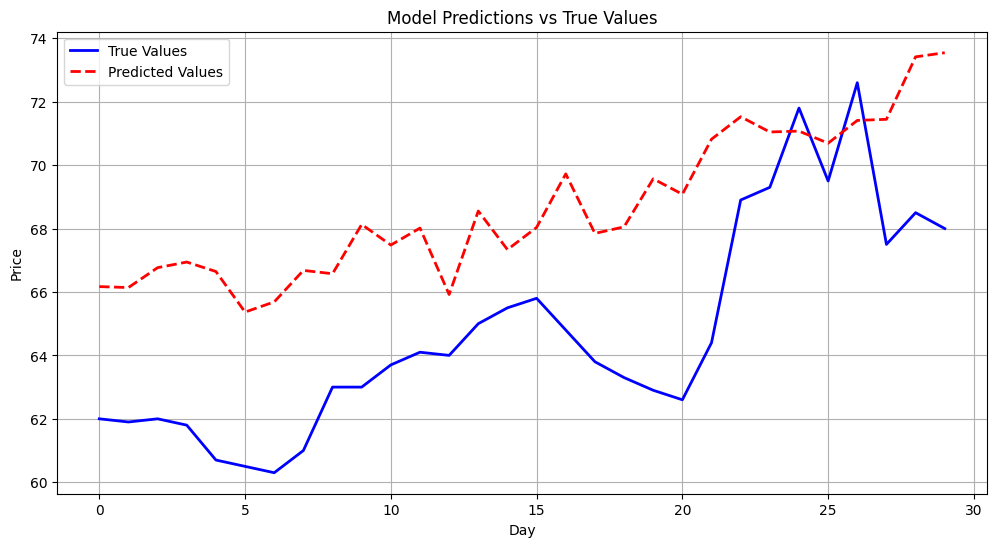

In [72]:
plot_model_result(model_output_dto=model_output_dto)